<a href="https://colab.research.google.com/github/taissa-arruda/prog_estat/blob/main/Resolu%C3%A7%C3%A3o_labs/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercício 1.1**

In [ ]:
import numpy as np
import time

def binomial_ingenuo(n, p):
    bernoullis = (np.random.uniform(size=n) < p).astype(int)
    return np.sum(bernoullis)

n = 50
p = 0.5
M = 1000

amostra_ingenua = np.array([binomial_ingenuo(n, p) for _ in range(M)])
amostra_ingenua

array([26, 24, 30, 29, 31, 23, 25, 27, 23, 24, 28, 25, 29, 31, 20, 25, 27,
       23, 28, 31, 22, 22, 24, 27, 18, 27, 27, 22, 21, 23, 25, 23, 28, 22,
       21, 21, 25, 24, 19, 29, 21, 20, 30, 24, 26, 28, 31, 27, 18, 23, 26,
       26, 18, 20, 21, 21, 19, 30, 26, 26, 27, 31, 25, 20, 25, 26, 27, 26,
       25, 25, 26, 26, 25, 24, 24, 24, 24, 27, 26, 15, 22, 23, 23, 26, 24,
       25, 25, 30, 31, 23, 29, 27, 20, 33, 24, 23, 26, 26, 26, 30, 32, 29,
       28, 20, 30, 25, 32, 23, 21, 23, 25, 25, 27, 24, 28, 31, 25, 22, 24,
       24, 29, 28, 25, 28, 23, 27, 24, 25, 19, 27, 25, 22, 30, 27, 27, 24,
       21, 22, 25, 25, 28, 26, 29, 24, 24, 26, 24, 25, 24, 22, 20, 25, 23,
       28, 29, 18, 23, 24, 27, 27, 23, 23, 24, 24, 20, 25, 28, 20, 26, 26,
       30, 28, 25, 31, 27, 21, 29, 29, 28, 19, 23, 28, 27, 28, 23, 26, 26,
       25, 24, 24, 28, 30, 23, 23, 22, 24, 23, 26, 30, 28, 22, 30, 26, 24,
       28, 28, 25, 23, 25, 26, 24, 29, 22, 23, 19, 24, 21, 19, 33, 26, 28,
       19, 22, 23, 26, 20

**Exercício 1.2**

In [ ]:
def binomial_recursivo(n, p):
    U = np.random.uniform()

    i = 0
    pi = (1 - p) ** n
    F = pi

    while U > F:
        pi = ((n - i) / (i + 1)) * (p / (1 - p)) * pi
        i += 1
        F += pi

    return i

amostra_recursiva = np.array([binomial_recursivo(n, p) for _ in range(M)])
amostra_recursiva

array([20, 26, 25, 20, 27, 24, 31, 26, 26, 22, 33, 27, 24, 26, 25, 26, 28,
       21, 25, 21, 30, 25, 26, 24, 23, 31, 22, 26, 28, 24, 28, 23, 19, 31,
       31, 21, 26, 25, 26, 27, 25, 30, 24, 28, 23, 20, 24, 32, 21, 33, 18,
       26, 23, 28, 22, 22, 28, 24, 32, 29, 25, 25, 33, 26, 30, 23, 26, 25,
       21, 28, 31, 26, 25, 29, 23, 25, 22, 19, 27, 24, 25, 29, 26, 30, 26,
       27, 23, 21, 27, 30, 29, 27, 26, 28, 24, 26, 27, 25, 27, 26, 28, 32,
       22, 31, 26, 29, 29, 28, 24, 21, 25, 20, 22, 23, 21, 28, 26, 29, 24,
       19, 21, 25, 21, 28, 27, 23, 27, 22, 29, 26, 23, 22, 28, 23, 24, 23,
       17, 21, 26, 25, 29, 28, 17, 26, 20, 30, 28, 25, 24, 27, 38, 22, 19,
       23, 20, 29, 21, 25, 29, 22, 22, 26, 20, 21, 22, 24, 29, 18, 31, 26,
       21, 23, 22, 24, 22, 23, 27, 28, 33, 24, 27, 27, 21, 22, 31, 23, 24,
       31, 20, 22, 26, 25, 20, 23, 23, 27, 31, 30, 24, 28, 23, 28, 27, 28,
       26, 23, 26, 25, 29, 24, 25, 30, 23, 22, 26, 23, 32, 21, 29, 29, 24,
       27, 24, 26, 26, 22

**Exercício 1.3**

In [ ]:
import time

valores_p = np.linspace(0.1, 0.9, 5)
valores_n = np.linspace(10, 200, 5, dtype=int)

resultados = []

for n in valores_n:
    for p in valores_p:

        # Tempo do método ingênuo
        tempos_ingenuo = []
        for _ in range(100):
            inicio = time.time()
            binomial_ingenuo(n, p)
            fim = time.time()
            tempos_ingenuo.append(fim - inicio)
        tempo_medio_ingenuo = np.mean(tempos_ingenuo)

        # Tempo do método recursivo
        tempos_recursivo = []
        for _ in range(100):
            inicio = time.time()
            binomial_recursivo(n, p)
            fim = time.time()
            tempos_recursivo.append(fim - inicio)
        tempo_medio_recursivo = np.mean(tempos_recursivo)

        resultados.append({
            'n': n,
            'p': p,
            'tempo_ingenuo': tempo_medio_ingenuo,
            'tempo_recursivo': tempo_medio_recursivo
        })

resultados

[{'n': np.int64(10),
  'p': np.float64(0.1),
  'tempo_ingenuo': np.float64(2.2690296173095704e-05),
  'tempo_recursivo': np.float64(9.381771087646485e-06)},
 {'n': np.int64(10),
  'p': np.float64(0.30000000000000004),
  'tempo_ingenuo': np.float64(2.4895668029785157e-05),
  'tempo_recursivo': np.float64(1.1699199676513672e-05)},
 {'n': np.int64(10),
  'p': np.float64(0.5),
  'tempo_ingenuo': np.float64(1.968860626220703e-05),
  'tempo_recursivo': np.float64(1.512289047241211e-05)},
 {'n': np.int64(10),
  'p': np.float64(0.7000000000000001),
  'tempo_ingenuo': np.float64(1.9593238830566408e-05),
  'tempo_recursivo': np.float64(1.7511844635009766e-05)},
 {'n': np.int64(10),
  'p': np.float64(0.9),
  'tempo_ingenuo': np.float64(1.975536346435547e-05),
  'tempo_recursivo': np.float64(2.0594596862792968e-05)},
 {'n': np.int64(57),
  'p': np.float64(0.1),
  'tempo_ingenuo': np.float64(2.1047592163085938e-05),
  'tempo_recursivo': np.float64(1.562833786010742e-05)},
 {'n': np.int64(57),
  'p'

**Exercício 1.4**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Organizando os resultados em tabela
df_resultados = pd.DataFrame(resultados)
df_resultados

,n,p,tempo_ingenuo,tempo_recursivo
0,10,0.1,0.000023,0.000009
1,10,0.3,0.000025,0.000012
2,10,0.5,0.000020,0.000015
3,10,0.7,0.000020,0.000018
4,10,0.9,0.000020,0.000021
5,57,0.1,0.000021,0.000016
6,57,0.3,0.000021,0.000032
7,57,0.5,0.000021,0.000048
8,57,0.7,0.000021,0.000065
9,57,0.9,0.000021,0.000081


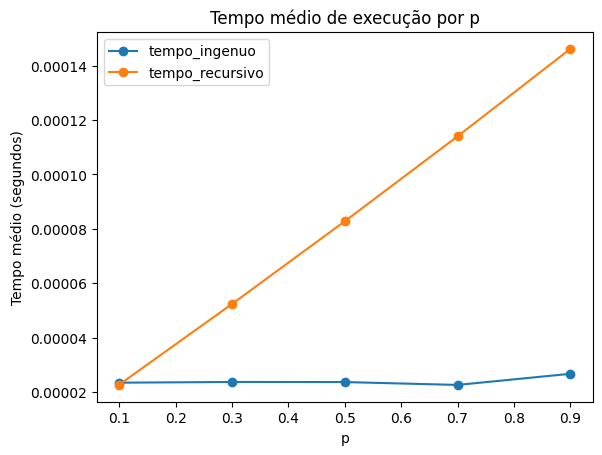

In [ ]:
# Gráfico: tempo médio de execução por p
medias_por_p = df_resultados.groupby('p')[['tempo_ingenuo', 'tempo_recursivo']].mean()

medias_por_p.plot(marker='o')
plt.title('Tempo médio de execução por p')
plt.xlabel('p')
plt.ylabel('Tempo médio (segundos)')
plt.show()

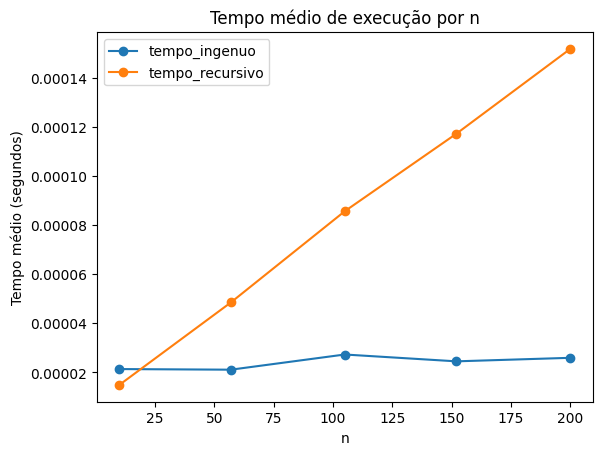

In [ ]:
# Gráfico: tempo médio de execução por n
medias_por_n = df_resultados.groupby('n')[['tempo_ingenuo', 'tempo_recursivo']].mean()

medias_por_n.plot(marker='o')
plt.title('Tempo médio de execução por n')
plt.xlabel('n')
plt.ylabel('Tempo médio (segundos)')
plt.show()

**Comentário:**

O gráfico mostra uma diferença clara entre os dois métodos. O método ingênuo se mantém praticamente estável, sem variar muito com p — faz sentido, já que ele sempre gera n números uniformes, não importa o valor de p. Já o método recursivo varia bastante: o tempo sobe quando p está perto de 0.5 e cai quando p se aproxima de 0 ou de 1. Isso acontece porque ele percorre os valores possíveis de X um a um até achar onde o U caiu, e quando p está perto de 0.5 a distribuição fica mais espalhada, exigindo mais iterações do while. Já perto de 0 ou 1, a distribuição fica mais concentrada e o while converge rápido. Ou seja, o método ingênuo tem custo praticamente constante, enquanto o recursivo é mais lento justamente quando há mais incerteza (p perto de 0.5).